In [1]:
!pip install -q huggingface_hub scikit-learn transformers pytorch_metric_learning peft onnxscript  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.2 MB/s eta 0:00:00


In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
token = user_secrets.get_secret("HF_TOKEN")

login(token=token)

In [3]:
!hf download facebook/dinov3-vitb16-pretrain-lvd1689m --local-dir ./DINOv3

A new version of huggingface_hub (1.14.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

Fetching 6 files: 100%|███████████████████████████| 6/6 [00:03<00:00,  1.99it/s]
Download complete: : 343MB [00:03, 25.7MB/s]              /kaggle/working/DINOv3


In [4]:
!kaggle datasets download amlanmohanty1/dragon-ball-anime-dataset

Dataset URL: https://www.kaggle.com/datasets/amlanmohanty1/dragon-ball-anime-dataset
License(s): other
100%|███████████████████████████████████████| 57.9M/57.9M [00:00<00:00, 123MB/s]



In [5]:
!kaggle datasets download angelirodriguez/jujutsu-kaisen-character-dataset

Dataset URL: https://www.kaggle.com/datasets/angelirodriguez/jujutsu-kaisen-character-dataset
License(s): MIT
100%|███████████████████████████████████████| 3.43G/3.43G [00:21<00:00, 171MB/s]



In [6]:
!kaggle datasets download balabaskar/tom-and-jerry-image-classification

Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100%|█████████████████████████████████████████| 435M/435M [00:02<00:00, 182MB/s]



In [7]:
!kaggle datasets download ibrahimserouis99/one-piece-image-classifier

Dataset URL: https://www.kaggle.com/datasets/ibrahimserouis99/one-piece-image-classifier
License(s): GPL-2.0
100%|███████████████████████████████████████| 2.53G/2.53G [00:14<00:00, 182MB/s]



In [8]:
import requests

url = "https://data.mendeley.com/public-api/zip/fzrj2xc9rt/download/2"
output_file = "dataset.zip"

response = requests.get(url, stream=True)

response.raise_for_status()  

with open(output_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print(f"Downloaded successfully: {output_file}")

Downloaded successfully: dataset.zip


In [9]:
import os
import zipfile
import io

# --- Configuration ---
SOURCE_DIR = "./"
TARGET_DIR = "./images"
EXCLUDED_NAMES = {"tom_jerry_0", "tom_jerry_1", "Civilians", "Curse", "Curse users", "Sorcerer"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def process_zips():
    if not os.path.exists(TARGET_DIR):
        os.makedirs(TARGET_DIR)

    zip_files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.zip')]

    for zip_name in zip_files:
        zip_path = os.path.join(SOURCE_DIR, zip_name)
        
        with open(zip_path, 'rb') as f:
            zip_data = io.BytesIO(f.read())

        os.remove(zip_path)

        with zipfile.ZipFile(zip_data) as z:
            for member in z.infolist():
                if member.is_dir():
                    continue

                ext = os.path.splitext(member.filename)[1].lower()
                if ext in IMAGE_EXTENSIONS:
                    path_parts = member.filename.split('/')
                    
                    if len(path_parts) >= 2:
                        char_name = path_parts[-2]
                        filename = path_parts[-1]
                        
                        if char_name in EXCLUDED_NAMES:
                            continue
                        
                        dest_folder = os.path.join(TARGET_DIR, char_name)
                        os.makedirs(dest_folder, exist_ok=True)
                        
                        unique_filename = f"{zip_name.split('.')[0]}_{filename}"
                        dest_path = os.path.join(dest_folder, unique_filename)
                        
                        with z.open(member) as source_file, open(dest_path, 'wb') as target_file:
                            target_file.write(source_file.read())

        print(f"Finished processing {zip_name}")

if __name__ == "__main__":
    process_zips()

Finished processing one-piece-image-classifier.zip
Finished processing tom-and-jerry-image-classification.zip
Finished processing dragon-ball-anime-dataset.zip
Finished processing dataset.zip
Finished processing jujutsu-kaisen-character-dataset.zip


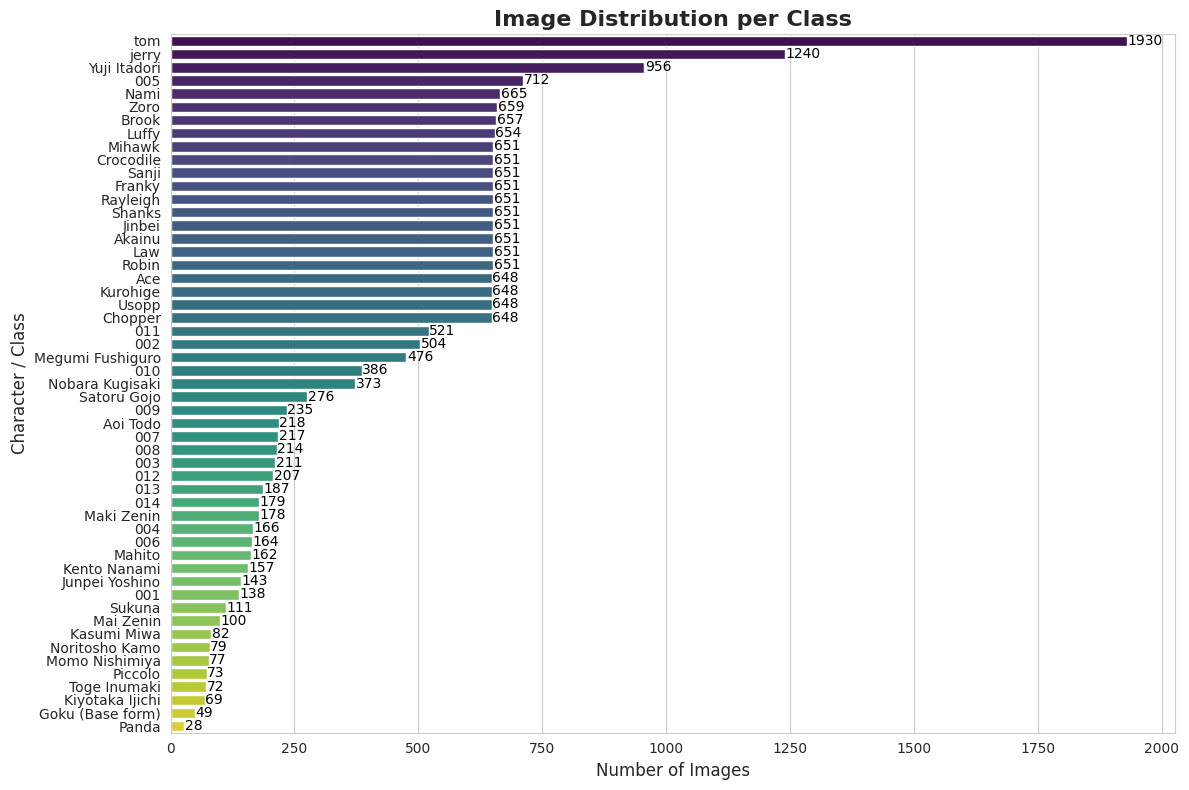

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
TARGET_DIR = "./images"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
def plot_distribution(data_path):
    stats = {}
    for class_name in os.listdir(data_path):
        class_folder = os.path.join(data_path, class_name)
        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder) 
                if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS
            ])
            stats[class_name] = count

    sorted_stats = dict(sorted(stats.items(), key=lambda item: item[1], reverse=True))
    names = list(sorted_stats.keys())
    counts = list(sorted_stats.values())

    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    ax = sns.barplot(x=counts, y=names, hue=names, palette="viridis", legend=False)

    plt.xlabel("Number of Images", fontsize=12)
    plt.ylabel("Character / Class", fontsize=12)
    plt.title("Image Distribution per Class", fontsize=16, fontweight='bold')

    for i, v in enumerate(counts):
        ax.text(v + 1, i, str(v), color='black', va='center')

    plt.tight_layout()
    plt.show()
    
if __name__ == "__main__":
    if os.path.exists(TARGET_DIR):
        plot_distribution(TARGET_DIR)
    else:
        print(f"Directory {TARGET_DIR} not found!")

In [11]:
import os
import random
import cv2
import albumentations as A
from tqdm import tqdm

SOURCE_DIR = "./images"
OUTPUT_DIR = "./dataset"
TARGET_TOTAL = 150
TARGET_SIZE = 448
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

TRAIN_TARGET = int(TARGET_TOTAL * TRAIN_RATIO)

base_processor = A.Compose([
    A.LongestMaxSize(max_size=TARGET_SIZE, interpolation=cv2.INTER_AREA),
    A.PadIfNeeded(
        min_height=TARGET_SIZE, 
        min_width=TARGET_SIZE, 
        border_mode=cv2.BORDER_CONSTANT, 
        fill_value=[128, 128, 128]
    )
])

augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)}, 
        scale=(0.95, 1.05), 
        rotate=(-15, 15), 
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
])

def prepare_dataset():
    if not os.path.exists(SOURCE_DIR):
        print(f"Error: {SOURCE_DIR} not found.")
        return

    classes = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))]

    for cls in tqdm(classes, desc="Processing Classes"):
        cls_path = os.path.join(SOURCE_DIR, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        
        random.shuffle(images)

        n = len(images)
        train_end = int(n * TRAIN_RATIO)
        val_end = train_end + int(n * VAL_RATIO)

        splits = {
            'train': images[:train_end],
            'val': images[train_end:val_end],
            'test': images[val_end:]
        }

        for split_name, split_images in splits.items():
            dest_dir = os.path.join(OUTPUT_DIR, split_name, cls)
            os.makedirs(dest_dir, exist_ok=True)
            
            for img_name in split_images:
                img_path = os.path.join(cls_path, img_name)
                image = cv2.imread(img_path)
                if image is None: continue

                processed = base_processor(image=image)['image']
                cv2.imwrite(os.path.join(dest_dir, img_name), processed)

        train_dir = os.path.join(OUTPUT_DIR, 'train', cls)
        current_train_files = [f for f in os.listdir(train_dir) if not f.startswith('aug_')]
        
        if not current_train_files:
            continue

        num_to_augment = TRAIN_TARGET - len(os.listdir(train_dir))
        
        count = 0
        while count < num_to_augment:
            raw_img_name = random.choice(current_train_files)
            image = cv2.imread(os.path.join(train_dir, raw_img_name))
            if image is None: continue
            
            augmented = augmentor(image=image)['image']
            
            aug_name = f"aug_{count}_{raw_img_name}"
            cv2.imwrite(os.path.join(train_dir, aug_name), augmented)
            count += 1

if __name__ == "__main__":
    prepare_dataset()
    print(f"Dataset preparation complete! Target: {TARGET_TOTAL} images per class (split {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}).")

/tmp/ipykernel_23/1203479892.py:19: UserWarning: Argument(s) 'fill_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
Processing Classes: 100%|██████████| 53/53 [11:00<00:00, 12.46s/it]

Dataset preparation complete! Target: 150 images per class (split 0.8/0.1/0.1).


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoModel
from peft import LoraConfig, get_peft_model
from pytorch_metric_learning import losses, samplers
import random
import warnings
from torch.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")

BATCH_SIZE    = 176
EVAL_BATCH_SIZE = BATCH_SIZE 
NUM_WORKERS   = 4
NUM_EPOCHS    = 6
EVAL_FREQ     = 1
PROJ_DIM      = 224
HIDDEN_DIM    = 768         
COMBINED_DIM  = HIDDEN_DIM * 2  

USE_CUDA  = torch.cuda.is_available()
device    = torch.device("cuda" if USE_CUDA else "cpu")

class GeMPooling(nn.Module):
    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clamp(min=self.eps).pow(self.p)
        x = x.mean(dim=1)
        return x.pow(1.0 / self.p)

class DINOv3FeatureExtractor(nn.Module):
    def __init__(self, model_path: str = "DINOv3", proj_dim: int = PROJ_DIM):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_path, dtype=torch.float16)

        lora_config = LoraConfig(
            r=16, lora_alpha=32, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], bias="none"
        )
        self.backbone = get_peft_model(self.backbone, lora_config)
        self.backbone.gradient_checkpointing_enable()

        self.gem = GeMPooling()
        self.head = nn.Sequential(
            nn.Linear(COMBINED_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )

    def forward(self, pixel_values: torch.Tensor, extract_features_only: bool = False) -> torch.Tensor:
        outputs    = self.backbone(pixel_values=pixel_values)
        last_hidden = outputs.last_hidden_state
        cls_token    = last_hidden[:, 0, :] 
        patch_tokens = last_hidden[:, 5:, :]
        gem_features = self.gem(patch_tokens)
        combined     = torch.cat([cls_token, gem_features], dim=1) 

        if extract_features_only:
            return F.normalize(combined, p=2, dim=1) 

        projected = self.head(combined)
        return F.normalize(projected, p=2, dim=1)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root="dataset/train", transform=transform)
val_dataset   = ImageFolder(root="dataset/val",   transform=transform)
test_dataset  = ImageFolder(root="dataset/test",  transform=transform)

train_targets = train_dataset.targets

sampler = samplers.MPerClassSampler(
    train_targets, m=4, batch_size=BATCH_SIZE, length_before_new_iter=len(train_dataset)
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=USE_CUDA
)

num_eval_samples = min(10000, len(train_dataset))
subset_indices = random.sample(range(len(train_dataset)), num_eval_samples)
eval_train_subset = Subset(train_dataset, subset_indices)

train_eval_loader = DataLoader(
    eval_train_subset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=USE_CUDA
)
val_loader = DataLoader(
    val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=USE_CUDA
)
test_loader = DataLoader(
    test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=USE_CUDA
)

model     = DINOv3FeatureExtractor("DINOv3").to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
loss_func = losses.SupConLoss()
scaler = GradScaler('cuda') if USE_CUDA else None

EARLY_STOPPING_PATIENCE = 2   
CHECKPOINT_PATH = "best_model.pt"

best_val_acc = 0.0
epochs_no_improve = 0

def extract_embeddings_gpu(eval_model: nn.Module, dataloader: DataLoader):
    eval_model.eval()
    all_embeddings, all_targets = [], []

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            with autocast('cuda' if USE_CUDA else 'cpu'):
                embeddings = eval_model(images, extract_features_only=True)
            
            all_embeddings.append(embeddings.cpu())
            all_targets.append(targets)

    return torch.cat(all_embeddings), torch.cat(all_targets)

def gpu_knn_accuracy(X_train_emb, y_train_emb, X_query_emb, y_query_emb, k=5):
    
    X_train_emb = X_train_emb.to(device)
    y_train_emb = y_train_emb.to(device)
    X_query_emb = X_query_emb.to(device)
    y_query_emb = y_query_emb.to(device)

    similarities = torch.mm(X_query_emb, X_train_emb.t())
    _, topk_indices = similarities.topk(k=k, dim=1)
    topk_labels = y_train_emb[topk_indices]
    preds = torch.mode(topk_labels, dim=1).values
    
    acc = (preds == y_query_emb).float().mean().item()
    
    del X_train_emb, y_train_emb, X_query_emb, y_query_emb, similarities, topk_indices, topk_labels, preds
    
    return acc

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", unit="batch", dynamic_ncols=True)
    for images, targets in pbar:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()

        if USE_CUDA:
            with autocast('cuda'):
                embeddings = model(images, extract_features_only=False)
                loss       = loss_func(embeddings, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            embeddings = model(images, extract_features_only=False)
            loss       = loss_func(embeddings, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  |  Loss: {avg_loss:.4f}  |  LR: {scheduler.get_last_lr()[0]:.2e}")

    if (epoch + 1) % EVAL_FREQ == 0 or (epoch + 1) == NUM_EPOCHS:
        if USE_CUDA:
            torch.cuda.empty_cache()
            
        X_train_emb, y_train_emb = extract_embeddings_gpu(model, train_eval_loader)
        X_val_emb,   y_val_emb   = extract_embeddings_gpu(model, val_loader)

        val_acc = gpu_knn_accuracy(X_train_emb, y_train_emb, X_val_emb, y_val_emb, k=5)
        print(f"Val KNN Accuracy: {val_acc * 100:.2f}%  ", end="")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print("New best — checkpoint saved.")
        else:
            epochs_no_improve += 1
            print(f"(no improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs)")
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                break

print(f"\nBest Val KNN Accuracy: {best_val_acc * 100:.2f}%")
print("\n--- Final Evaluation: KNN (k=5) on Test Set ---")

if USE_CUDA:
    torch.cuda.empty_cache()

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
X_train_emb, y_train_emb = extract_embeddings_gpu(model, train_eval_loader)
X_test_emb,  y_test_emb  = extract_embeddings_gpu(model, test_loader)
test_acc = gpu_knn_accuracy(X_train_emb, y_train_emb, X_test_emb, y_test_emb, k=5)

print(f"Test Accuracy (KNN k=5): {test_acc * 100:.2f}%")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Epoch 1/6: 100%|██████████| 106/106 [18:47<00:00, 10.64s/batch, loss=1.8151]

Epoch 1/6  |  Loss: 2.4515  |  LR: 9.33e-05


Val KNN Accuracy: 98.17%  New best — checkpoint saved.


Epoch 2/6: 100%|██████████| 106/106 [18:52<00:00, 10.69s/batch, loss=1.4448]


...

Epoch 5/6  |  Loss: 1.3057  |  LR: 6.70e-06


Val KNN Accuracy: 98.62%  (no improvement for 1/2 epochs)


Epoch 6/6: 100%|██████████| 106/106 [19:18<00:00, 10.93s/batch, loss=1.3253]

Epoch 6/6  |  Loss: 1.2882  |  LR: 0.00e+00


Val KNN Accuracy: 98.62%  (no improvement for 2/2 epochs)

Early stopping triggered at epoch 6.

Best Val KNN Accuracy: 98.66%

--- Final Evaluation: KNN (k=5) on Test Set ---
Test Accuracy (KNN k=5): 98.18%


In [13]:
import torch
import torch.nn as nn

class ONNXWrapper(nn.Module):
    def __init__(self, base_model, extract_features_only=False):
        super().__init__()
        self.base_model = base_model
        self.extract_features_only = extract_features_only
        
    def forward(self, pixel_values):
        return self.base_model(pixel_values, extract_features_only=self.extract_features_only)


wrapped_model = ONNXWrapper(model, extract_features_only=False)
wrapped_model.eval()

batch_size = 1
dummy_image_input = torch.randn(batch_size, 3, 224, 224).to(device)

onnx_path = "dino_v3.onnx"
print(f"Exporting model to {onnx_path}...")

with torch.no_grad():
    torch.onnx.export(
        wrapped_model, 
        dummy_image_input,            
        onnx_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=['pixel_values'], 
        output_names=['embeddings'],  
        dynamic_axes={
            'pixel_values': {0: 'batch_size'},
            'embeddings': {0: 'batch_size'}
        }
    )

print("ONNX export complete!")

Exporting model to dino_v3.onnx...


W0510 15:52:00.416000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 15:52:00.418000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 15:52:00.420000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0510 15:52:00.422000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ONNXWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ONNXWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export complete!


In [14]:
!rm -rf images/ dataset/ DINOv3/ .virtual_documents/ best_model.pt